# 股票趋势与动量分析

> 基于《stock_trend_analysis_spec.md》，对长江电力（600900.SH）进行趋势识别与动量诊断。
> 数据来源：cypower_daily_till_20260628.csv

## 前置：数据准备与收益率计算

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# macOS 中文字体配置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('cypower_daily_till_20260628.csv')
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values('trade_date').reset_index(drop=True)

# 计算前复权最高价、最低价（CSV 中未直接提供，需通过复权因子计算）
latest_adj = df['adj_factor'].iloc[-1]
df['high_qfq'] = df['high'] * df['adj_factor'] / latest_adj
df['low_qfq'] = df['low'] * df['adj_factor'] / latest_adj
df['close_qfq'] = df['close_qfq'].astype(float)

# 收益率计算
df['daily_return'] = df['close_qfq'].pct_change()
df['cum_return'] = (1 + df['daily_return']).cumprod() - 1

print(f'数据范围：{df["trade_date"].iloc[0].date()} ~ {df["trade_date"].iloc[-1].date()}')
print(f'总交易日数：{len(df)}')
print(f'前复权收盘价范围：{df["close_qfq"].min():.2f} ~ {df["close_qfq"].max():.2f}')
df.head()

数据范围：2025-06-30 ~ 2026-06-26
总交易日数：241
前复权收盘价范围：25.45 ~ 29.63


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,adj_factor,close_hfq,close_qfq,close_raw,high_qfq,low_qfq,daily_return,cum_return
0,600900.SH,2025-06-30,30.23,30.42,30.10,30.14,30.22,-0.08,-0.2647,755184.56,2282994.819,3.6703,110.622842,29.177307,30.14,29.448364,29.138585,NaN,NaN
1,600900.SH,2025-07-01,30.20,30.52,30.15,30.37,30.14,0.23,0.7631,594762.75,1806986.262,3.6703,111.467011,29.399961,30.37,29.545170,29.186988,0.007631,0.007631
2,600900.SH,2025-07-02,30.40,30.48,30.22,30.25,30.37,-0.12,-0.3951,571834.95,1734049.631,3.6703,111.026575,29.283794,30.25,29.506447,29.254752,-0.003951,0.003650
3,600900.SH,2025-07-03,30.26,30.28,29.85,30.09,30.25,-0.16,-0.5289,936811.23,2811204.131,3.6703,110.439327,29.128904,30.09,29.312835,28.896570,-0.005289,-0.001659
4,600900.SH,2025-07-04,30.06,30.29,30.01,30.16,30.09,0.07,0.2326,679228.05,2048728.031,3.6703,110.696248,29.196668,30.16,29.322516,29.051459,0.002326,0.000664


---
## 模块 1：移动均线与趋势判断

=== 均线排列判断（最新交易日） ===
收盘价: 26.65
MA5: 26.66
MA10: 27.00
MA20: 27.37
MA60: 27.02
MA120: 26.87

判定：交叉排列（趋势不明确）
MA5-MA20：MA5 在 MA20 下方运行


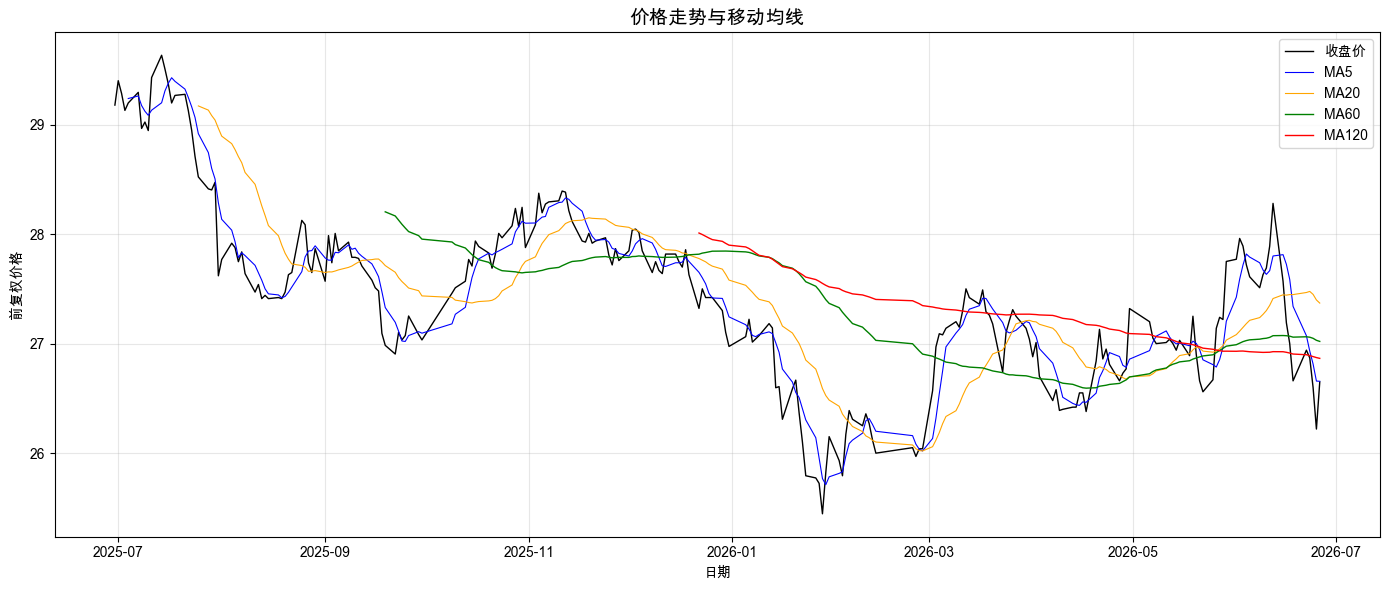

In [2]:
# 计算移动均线
for period in [5, 10, 20, 60, 120, 250]:
    df[f'MA{period}'] = df['close_qfq'].rolling(period).mean()

df['EMA12'] = df['close_qfq'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close_qfq'].ewm(span=26, adjust=False).mean()

# 趋势判断（最新交易日）
last = df.iloc[-1]
print('=== 均线排列判断（最新交易日） ===')
print(f'收盘价: {last["close_qfq"]:.2f}')
for p in [5, 10, 20, 60, 120]:
    val = last[f'MA{p}']
    if pd.notna(val):
        print(f'MA{p}: {val:.2f}')

# 多头/空头排列判断
if pd.notna(last['MA20']) and pd.notna(last['MA60']) and pd.notna(last['MA120']):
    if last['close_qfq'] > last['MA20'] > last['MA60'] > last['MA120']:
        print('\n判定：多头排列（强势上涨趋势）')
    elif last['close_qfq'] < last['MA20'] < last['MA60'] < last['MA120']:
        print('\n判定：空头排列（弱势下跌趋势）')
    else:
        print('\n判定：交叉排列（趋势不明确）')

# MA5-MA20 金叉/死叉
if len(df) >= 2:
    prev = df.iloc[-2]
    if pd.notna(prev['MA5']) and pd.notna(prev['MA20']):
        if prev['MA5'] <= prev['MA20'] and last['MA5'] > last['MA20']:
            print('MA5-MA20：金叉（短期买入信号）')
        elif prev['MA5'] >= prev['MA20'] and last['MA5'] < last['MA20']:
            print('MA5-MA20：死叉（短期卖出信号）')
        else:
            pos = '上方' if last['MA5'] > last['MA20'] else '下方'
            print(f'MA5-MA20：MA5 在 MA20 {pos}运行')

# 绘图
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['trade_date'], df['close_qfq'], label='收盘价', color='black', linewidth=1)
ax.plot(df['trade_date'], df['MA5'], label='MA5', color='blue', linewidth=0.8)
ax.plot(df['trade_date'], df['MA20'], label='MA20', color='orange', linewidth=0.8)
ax.plot(df['trade_date'], df['MA60'], label='MA60', color='green', linewidth=1)
ax.plot(df['trade_date'], df['MA120'], label='MA120', color='red', linewidth=1)
ax.set_title('价格走势与移动均线', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('前复权价格')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 模块 2：MACD（指数平滑异同移动平均线）

=== MACD 信号判断 ===
DIF: -0.1669, DEA: -0.0192, MACD柱: -0.2955
DIF 在 DEA 下方运行
DIF 位置：零轴下方
MACD 柱方向：多头放大


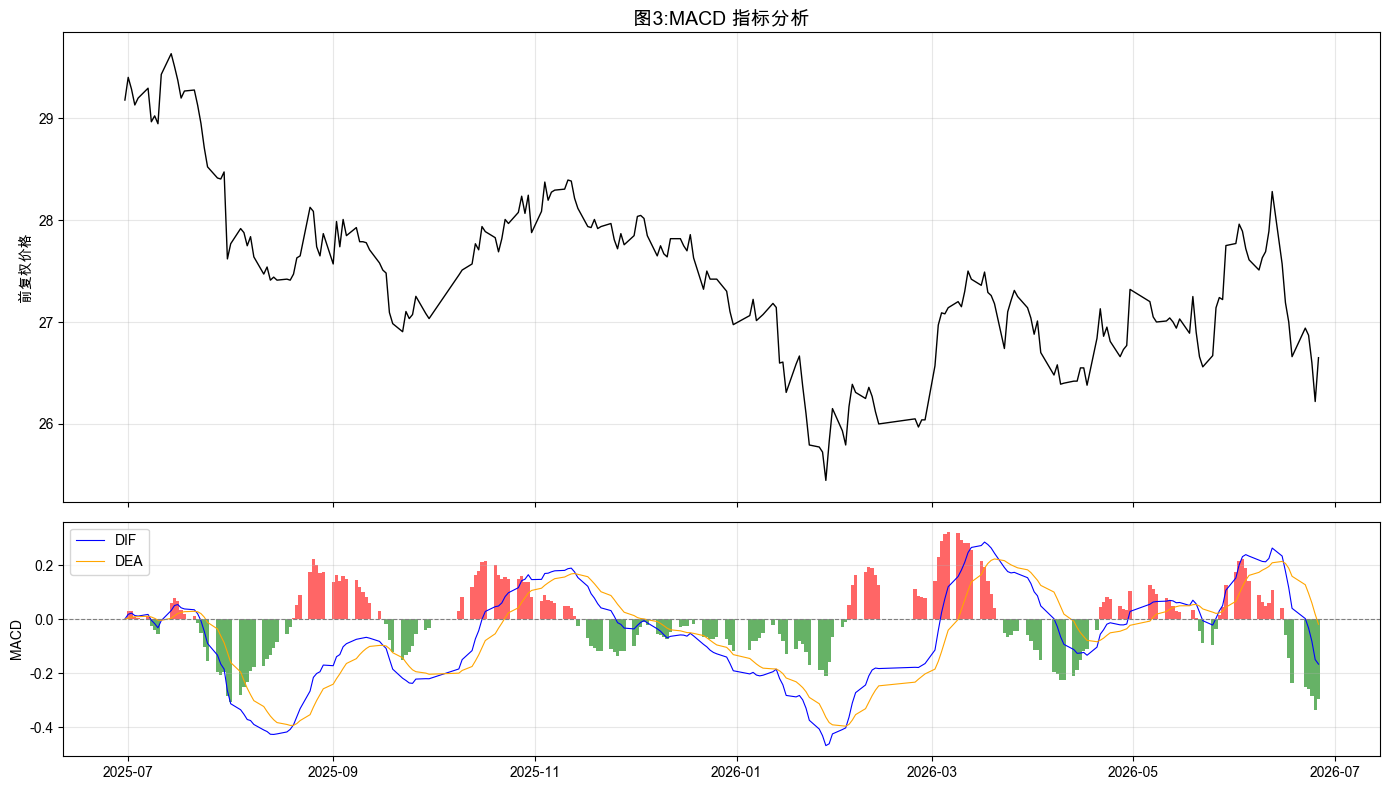

In [11]:
# MACD 计算
df['DIF'] = df['EMA12'] - df['EMA26']
df['DEA'] = df['DIF'].ewm(span=9, adjust=False).mean()
df['MACD_bar'] = 2 * (df['DIF'] - df['DEA'])

# 信号判断（最新交易日）
last = df.iloc[-1]
prev = df.iloc[-2]
print('=== MACD 信号判断 ===')
print(f'DIF: {last["DIF"]:.4f}, DEA: {last["DEA"]:.4f}, MACD柱: {last["MACD_bar"]:.4f}')

# 金叉/死叉判断
if prev['DIF'] <= prev['DEA'] and last['DIF'] > last['DEA']:
    pos = '零轴上方' if last['DIF'] > 0 else '零轴下方'
    print(f'信号：金叉（{pos}）')
elif prev['DIF'] >= prev['DEA'] and last['DIF'] < last['DEA']:
    pos = '零轴上方' if last['DIF'] > 0 else '零轴下方'
    print(f'信号：死叉（{pos}）')
else:
    pos = '上方' if last['DIF'] > last['DEA'] else '下方'
    print(f'DIF 在 DEA {pos}运行')

zero_pos = '零轴上方' if last['DIF'] > 0 else '零轴下方'
print(f'DIF 位置：{zero_pos}')
print(f'MACD 柱方向：{"多头放大" if last["MACD_bar"] > prev["MACD_bar"] else "多头缩小" if last["MACD_bar"] > 0 else "空头缩小" if last["MACD_bar"] > prev["MACD_bar"] else "空头放大"}')

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

ax1.plot(df['trade_date'], df['close_qfq'], color='black', linewidth=1)
ax1.set_title('图3:MACD 指标分析', fontsize=14)
ax1.set_ylabel('前复权价格')
ax1.grid(True, alpha=0.3)

ax2.plot(df['trade_date'], df['DIF'], label='DIF', color='blue', linewidth=0.8)
ax2.plot(df['trade_date'], df['DEA'], label='DEA', color='orange', linewidth=0.8)
colors = ['red' if v >= 0 else 'green' for v in df['MACD_bar']]
ax2.bar(df['trade_date'], df['MACD_bar'], color=colors, alpha=0.6, width=1)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('MACD')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 模块 3：布林带（Bollinger Bands）

=== 布林带信号判断 ===
上轨: 28.49, 中轨: 27.37, 下轨: 26.25
带宽: 0.0819
%B: 0.1790
位置：价格接近下轨（潜在超卖）
带宽状态：开口（波动率扩张，趋势可能加速）


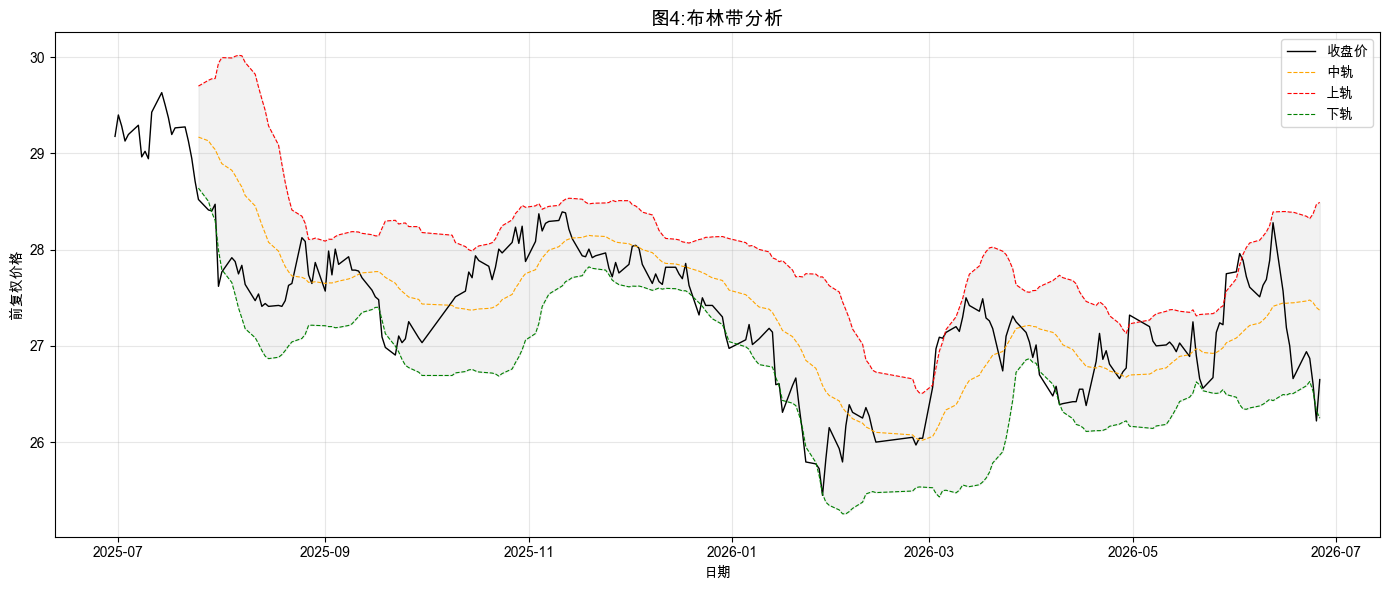

In [12]:
# 布林带计算
df['BB_MB'] = df['close_qfq'].rolling(20).mean()
df['BB_STD'] = df['close_qfq'].rolling(20).std()
df['BB_UP'] = df['BB_MB'] + 2 * df['BB_STD']
df['BB_DN'] = df['BB_MB'] - 2 * df['BB_STD']
df['BB_BW'] = (df['BB_UP'] - df['BB_DN']) / df['BB_MB']
df['BB_pctB'] = (df['close_qfq'] - df['BB_DN']) / (df['BB_UP'] - df['BB_DN'])

# 信号判断
last = df.iloc[-1]
print('=== 布林带信号判断 ===')
print(f'上轨: {last["BB_UP"]:.2f}, 中轨: {last["BB_MB"]:.2f}, 下轨: {last["BB_DN"]:.2f}')
print(f'带宽: {last["BB_BW"]:.4f}')
print(f'%B: {last["BB_pctB"]:.4f}')

if last['BB_pctB'] > 1:
    print('位置：价格突破上轨（超买）')
elif last['BB_pctB'] > 0.8:
    print('位置：价格接近上轨（潜在超买）')
elif last['BB_pctB'] < 0:
    print('位置：价格跌破下轨（超卖）')
elif last['BB_pctB'] < 0.2:
    print('位置：价格接近下轨（潜在超卖）')
else:
    print('位置：价格在布林带中部运行')

# 带宽状态
bw_mean = df['BB_BW'].mean()
bw_std = df['BB_BW'].std()
if last['BB_BW'] < bw_mean - bw_std:
    print('带宽状态：缩口（波动率压缩，预示变盘）')
elif last['BB_BW'] > bw_mean + bw_std:
    print('带宽状态：开口（波动率扩张，趋势可能加速）')
else:
    print('带宽状态：正常')

# 绘图
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['trade_date'], df['close_qfq'], label='收盘价', color='black', linewidth=1)
ax.plot(df['trade_date'], df['BB_MB'], label='中轨', color='orange', linestyle='--', linewidth=0.8)
ax.plot(df['trade_date'], df['BB_UP'], label='上轨', color='red', linestyle='--', linewidth=0.8)
ax.plot(df['trade_date'], df['BB_DN'], label='下轨', color='green', linestyle='--', linewidth=0.8)
ax.fill_between(df['trade_date'], df['BB_UP'], df['BB_DN'], alpha=0.1, color='gray')
ax.set_title('图4:布林带分析', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('前复权价格')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 模块 4：RSI（相对强弱指数）

=== RSI 信号判断 ===
RSI(6): 41.05, RSI(14): 42.77, RSI(24): 45.47
RSI(14)：中性


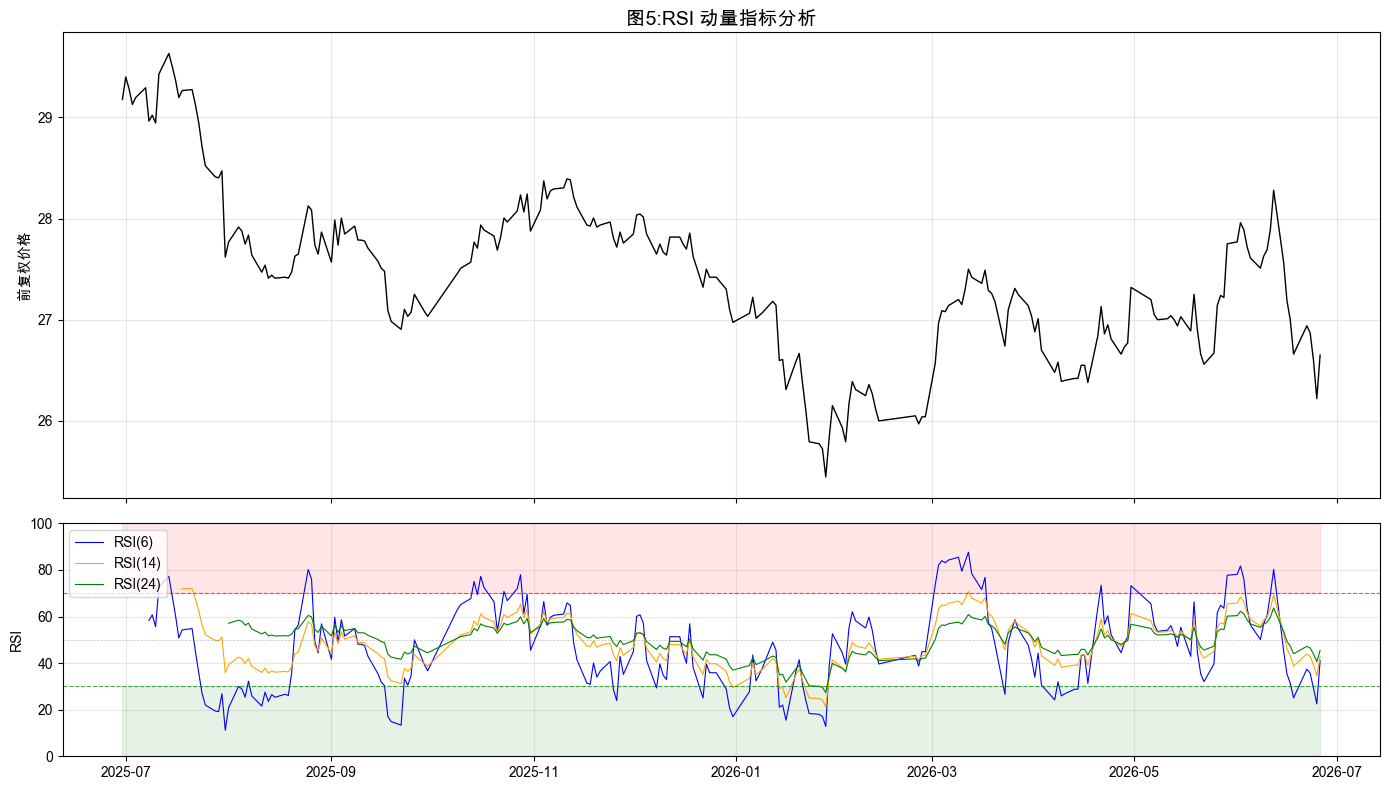

In [13]:
# RSI 计算（Wilder 平滑法）
def calc_rsi(series, period):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - 100 / (1 + rs)

df['RSI6'] = calc_rsi(df['close_qfq'], 6)
df['RSI14'] = calc_rsi(df['close_qfq'], 14)
df['RSI24'] = calc_rsi(df['close_qfq'], 24)

# 信号判断
last = df.iloc[-1]
prev = df.iloc[-2]
print('=== RSI 信号判断 ===')
print(f'RSI(6): {last["RSI6"]:.2f}, RSI(14): {last["RSI14"]:.2f}, RSI(24): {last["RSI24"]:.2f}')

rsi14 = last['RSI14']
if rsi14 > 80:
    print('RSI(14)：极度超买')
elif rsi14 > 70:
    print('RSI(14)：超买')
elif rsi14 < 20:
    print('RSI(14)：极度超卖')
elif rsi14 < 30:
    print('RSI(14)：超卖')
else:
    print('RSI(14)：中性')

# 金叉/死叉
if prev['RSI6'] <= prev['RSI24'] and last['RSI6'] > last['RSI24']:
    print('RSI 交叉：金叉（短期动量转强）')
elif prev['RSI6'] >= prev['RSI24'] and last['RSI6'] < last['RSI24']:
    print('RSI 交叉：死叉（短期动量转弱）')

# 背离检测（近 20 日）
recent = df.tail(20)
price_high_idx = recent['close_qfq'].idxmax()
price_low_idx = recent['close_qfq'].idxmin()
rsi_high_idx = recent['RSI14'].idxmax()
rsi_low_idx = recent['RSI14'].idxmin()

if price_high_idx != rsi_high_idx and abs(recent.loc[price_high_idx, 'close_qfq'] - recent['close_qfq'].max()) < 0.01:
    if recent.loc[price_high_idx, 'RSI14'] < recent.loc[rsi_high_idx, 'RSI14']:
        print('背离信号：疑似顶背离（价格创新高但 RSI 未创新高）')
if price_low_idx != rsi_low_idx and abs(recent.loc[price_low_idx, 'close_qfq'] - recent['close_qfq'].min()) < 0.01:
    if recent.loc[price_low_idx, 'RSI14'] > recent.loc[rsi_low_idx, 'RSI14']:
        print('背离信号：疑似底背离（价格创新低但 RSI 未创新低）')

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

ax1.plot(df['trade_date'], df['close_qfq'], color='black', linewidth=1)
ax1.set_title('图5:RSI 动量指标分析', fontsize=14)
ax1.set_ylabel('前复权价格')
ax1.grid(True, alpha=0.3)

ax2.plot(df['trade_date'], df['RSI6'], label='RSI(6)', color='blue', linewidth=0.8)
ax2.plot(df['trade_date'], df['RSI14'], label='RSI(14)', color='orange', linewidth=0.8)
ax2.plot(df['trade_date'], df['RSI24'], label='RSI(24)', color='green', linewidth=0.8)
ax2.axhline(y=70, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.axhline(y=50, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.axhline(y=30, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.fill_between(df['trade_date'], 70, 100, alpha=0.1, color='red')
ax2.fill_between(df['trade_date'], 0, 30, alpha=0.1, color='green')
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 模块 5：KDJ（随机指标）

=== KDJ 信号判断 ===
K: 15.17, D: 18.40, J: 8.72
K 在 D 下方运行


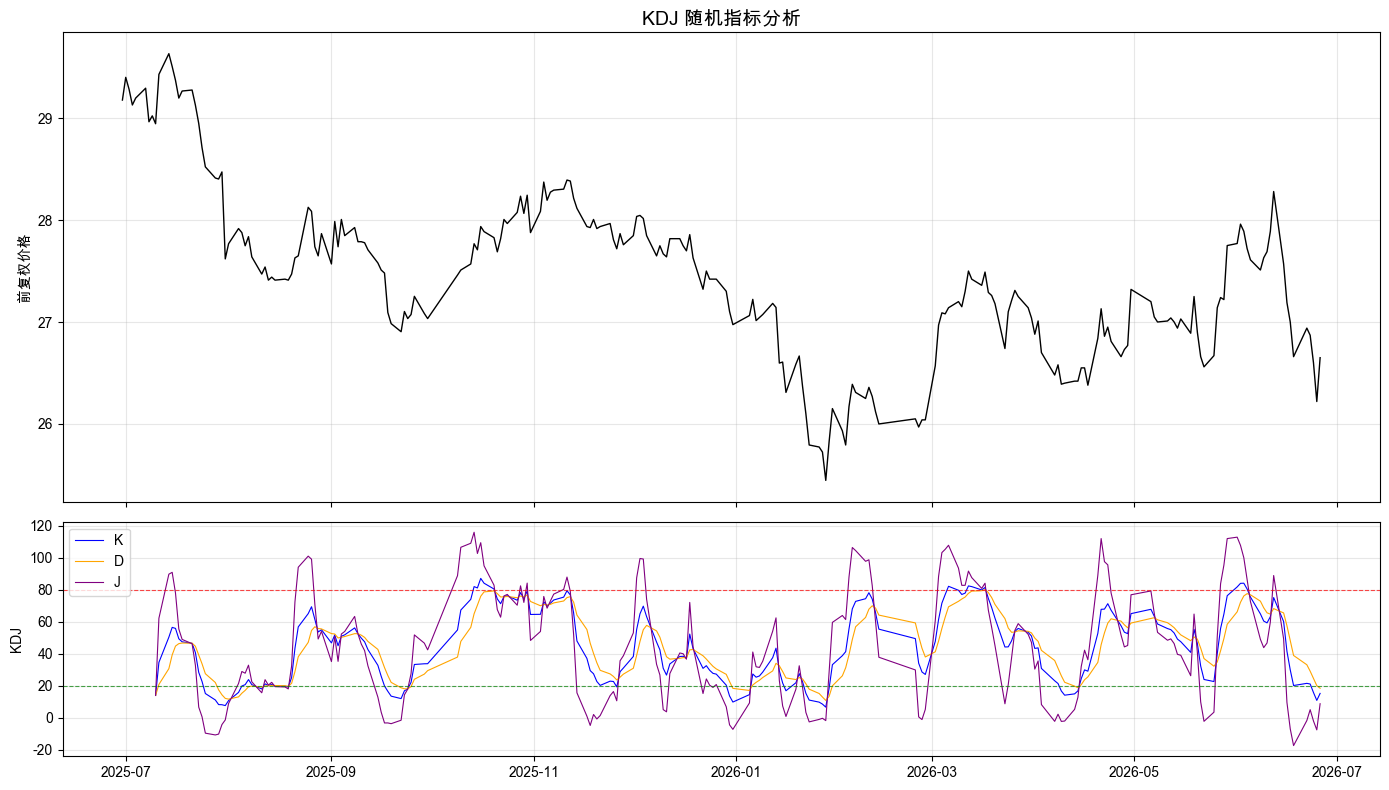

In [6]:
# KDJ 计算
low_9 = df['low_qfq'].rolling(9).min()
high_9 = df['high_qfq'].rolling(9).max()
df['RSV'] = (df['close_qfq'] - low_9) / (high_9 - low_9) * 100

# 使用 ewm(com=2) 即 alpha=1/3 的指数平滑
df['K'] = df['RSV'].ewm(com=2, adjust=False).mean()
df['D'] = df['K'].ewm(com=2, adjust=False).mean()
df['J'] = 3 * df['K'] - 2 * df['D']

# 信号判断
last = df.iloc[-1]
prev = df.iloc[-2]
print('=== KDJ 信号判断 ===')
print(f'K: {last["K"]:.2f}, D: {last["D"]:.2f}, J: {last["J"]:.2f}')

if last['J'] > 100:
    print('J 值 > 100：极度超买')
elif last['J'] < 0:
    print('J 值 < 0：极度超卖')

if prev['K'] <= prev['D'] and last['K'] > last['D']:
    zone = '超卖区' if last['K'] < 20 else '中性区' if last['K'] < 80 else '超买区'
    print(f'KDJ 交叉：金叉（{zone}，{"信号较强" if last["K"] < 20 else "信号一般"}）')
elif prev['K'] >= prev['D'] and last['K'] < last['D']:
    zone = '超买区' if last['K'] > 80 else '中性区' if last['K'] > 20 else '超卖区'
    print(f'KDJ 交叉：死叉（{zone}，{"信号较强" if last["K"] > 80 else "信号一般"}）')
else:
    pos = '上方' if last['K'] > last['D'] else '下方'
    print(f'K 在 D {pos}运行')

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

ax1.plot(df['trade_date'], df['close_qfq'], color='black', linewidth=1)
ax1.set_title('KDJ 随机指标分析', fontsize=14)
ax1.set_ylabel('前复权价格')
ax1.grid(True, alpha=0.3)

ax2.plot(df['trade_date'], df['K'], label='K', color='blue', linewidth=0.8)
ax2.plot(df['trade_date'], df['D'], label='D', color='orange', linewidth=0.8)
ax2.plot(df['trade_date'], df['J'], label='J', color='purple', linewidth=0.8)
ax2.axhline(y=80, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.axhline(y=20, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_ylabel('KDJ')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 模块 6：ATR（平均真实波幅）

=== ATR 信号判断 ===
ATR(14): 0.4593
ATR(20): 0.4685
ATR 百分比: 1.72%
波动状态：波动加剧（趋势可能加速或恐慌抛售）


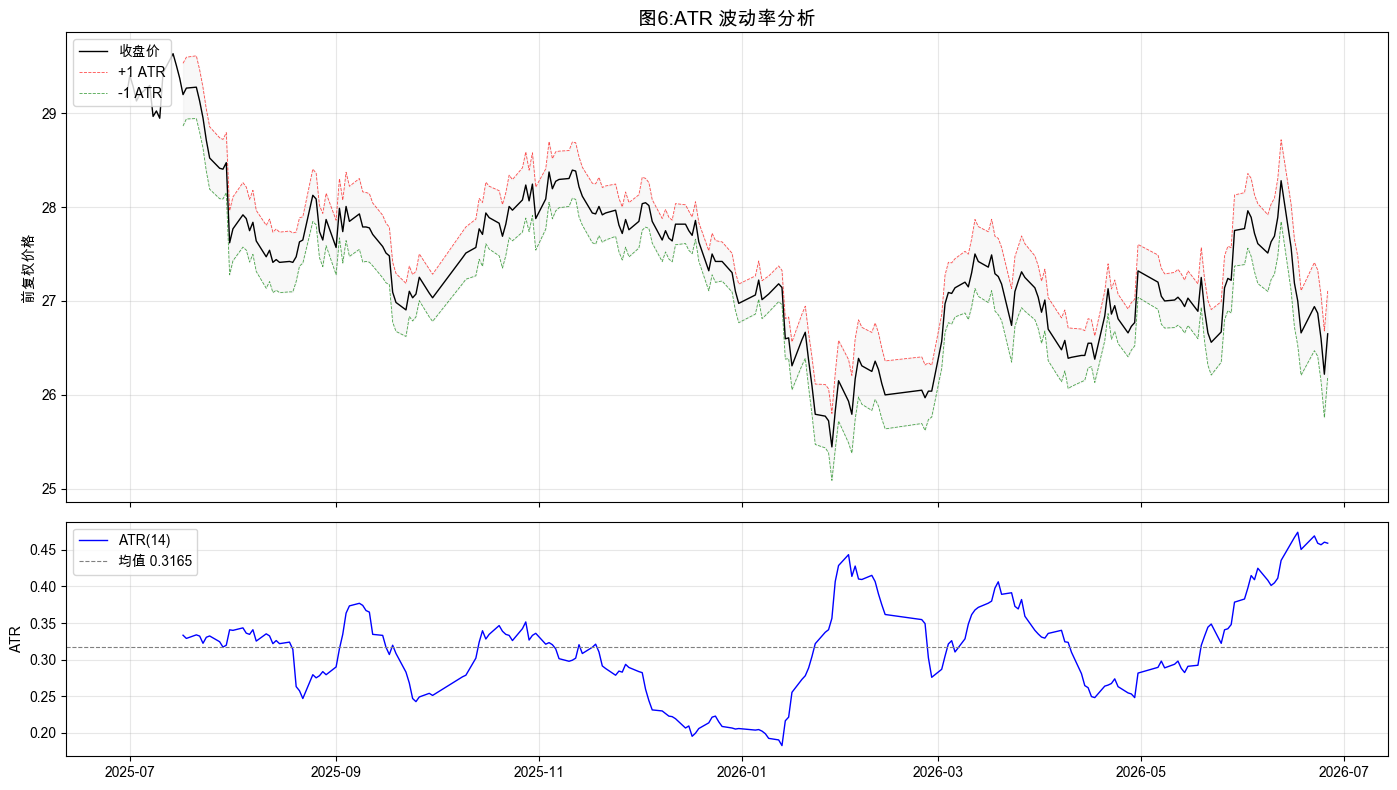

In [14]:
# ATR 计算
df['pre_close_adj'] = df['close_qfq'].shift(1)
tr1 = df['high_qfq'] - df['low_qfq']
tr2 = (df['high_qfq'] - df['pre_close_adj']).abs()
tr3 = (df['low_qfq'] - df['pre_close_adj']).abs()
df['TR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

df['ATR14'] = df['TR'].rolling(14).mean()
df['ATR20'] = df['TR'].rolling(20).mean()
df['ATR_pct'] = df['ATR14'] / df['close_qfq'] * 100

# 信号判断
last = df.iloc[-1]
print('=== ATR 信号判断 ===')
print(f'ATR(14): {last["ATR14"]:.4f}')
print(f'ATR(20): {last["ATR20"]:.4f}')
print(f'ATR 百分比: {last["ATR_pct"]:.2f}%')

atr_mean = df['ATR14'].mean()
if last['ATR14'] > atr_mean * 1.2:
    print('波动状态：波动加剧（趋势可能加速或恐慌抛售）')
elif last['ATR14'] < atr_mean * 0.8:
    print('波动状态：波动收窄（横盘整理或趋势减弱）')
else:
    print('波动状态：正常波动')

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

# 上图：价格 + ATR 通道
ax1.plot(df['trade_date'], df['close_qfq'], label='收盘价', color='black', linewidth=1)
atr_upper = df['close_qfq'] + df['ATR14']
atr_lower = df['close_qfq'] - df['ATR14']
ax1.plot(df['trade_date'], atr_upper, label='+1 ATR', color='red', linestyle='--', linewidth=0.6, alpha=0.7)
ax1.plot(df['trade_date'], atr_lower, label='-1 ATR', color='green', linestyle='--', linewidth=0.6, alpha=0.7)
ax1.fill_between(df['trade_date'], atr_upper, atr_lower, alpha=0.05, color='gray')
ax1.set_title('图6:ATR 波动率分析', fontsize=14)
ax1.set_ylabel('前复权价格')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 下图：ATR 折线
ax2.plot(df['trade_date'], df['ATR14'], label='ATR(14)', color='blue', linewidth=1)
ax2.axhline(y=atr_mean, color='gray', linestyle='--', linewidth=0.8, label=f'均值 {atr_mean:.4f}')
ax2.set_ylabel('ATR')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 模块 7：成交量分析

=== 量价关系判断 ===
量比: 1.00
成交量状态：正常
量价关系：缩量上涨（上涨动能不足）


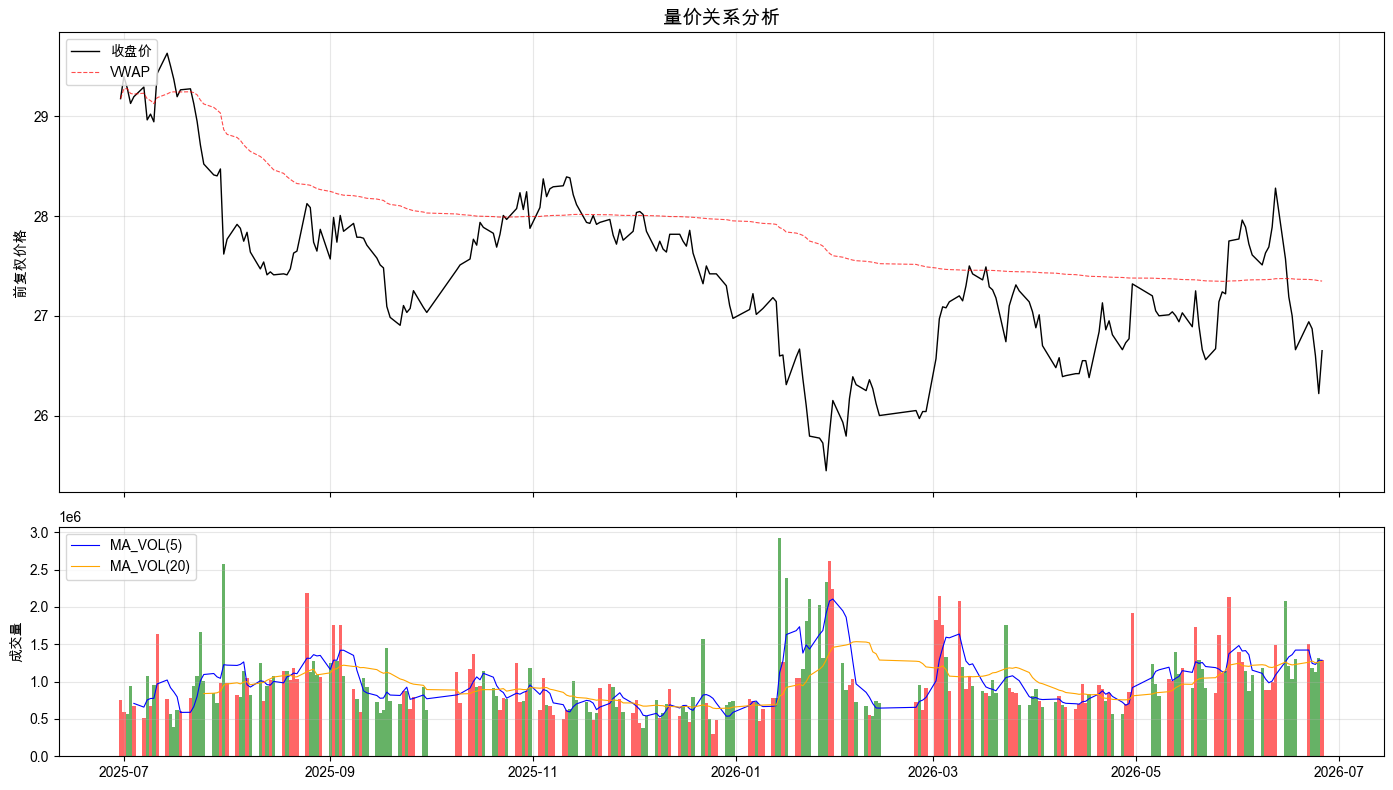

In [8]:
# 成交量指标计算
df['MA_VOL5'] = df['vol'].rolling(5).mean()
df['MA_VOL20'] = df['vol'].rolling(20).mean()
df['vol_ratio'] = df['vol'] / df['MA_VOL5']

# OBV 计算
direction = np.sign(df['close_qfq'].diff())
df['OBV'] = (direction * df['vol']).cumsum()

# VWAP 计算（全局累积）
df['VWAP'] = (df['close_qfq'] * df['vol']).cumsum() / df['vol'].cumsum()

# 量价关系判断（最新交易日）
last = df.iloc[-1]
prev = df.iloc[-2]
price_up = last['close_qfq'] > prev['close_qfq']
vol_up = last['vol'] > prev['vol']

print('=== 量价关系判断 ===')
print(f'量比: {last["vol_ratio"]:.2f}')
if last['vol_ratio'] > 1.5:
    print('成交量状态：明显放量')
elif last['vol_ratio'] > 1.0:
    print('成交量状态：温和放量')
elif last['vol_ratio'] < 0.5:
    print('成交量状态：明显缩量')
else:
    print('成交量状态：正常')

if price_up and vol_up:
    print('量价关系：量价齐升（上涨趋势健康）')
elif price_up and not vol_up:
    print('量价关系：缩量上涨（上涨动能不足）')
elif not price_up and vol_up:
    print('量价关系：放量下跌（恐慌性抛售）')
else:
    print('量价关系：缩量下跌（卖压减轻）')

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

# 上图：价格 + VWAP
ax1.plot(df['trade_date'], df['close_qfq'], label='收盘价', color='black', linewidth=1)
ax1.plot(df['trade_date'], df['VWAP'], label='VWAP', color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_title('量价关系分析', fontsize=14)
ax1.set_ylabel('前复权价格')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 下图：成交量
vol_colors = ['red' if c >= p else 'green' for c, p in zip(df['close_qfq'], df['close_qfq'].shift(1).fillna(df['close_qfq']))]
ax2.bar(df['trade_date'], df['vol'], color=vol_colors, alpha=0.6, width=1)
ax2.plot(df['trade_date'], df['MA_VOL5'], label='MA_VOL(5)', color='blue', linewidth=0.8)
ax2.plot(df['trade_date'], df['MA_VOL20'], label='MA_VOL(20)', color='orange', linewidth=0.8)
ax2.set_ylabel('成交量')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 模块 8：ADX（平均趋向指数）

=== ADX 信号判断 ===
ADX: 31.67
+DI: 15.26, -DI: 31.63
趋势强度：趋势明确
方向：下降趋势（-DI > +DI）
ADX 方向：趋势减弱


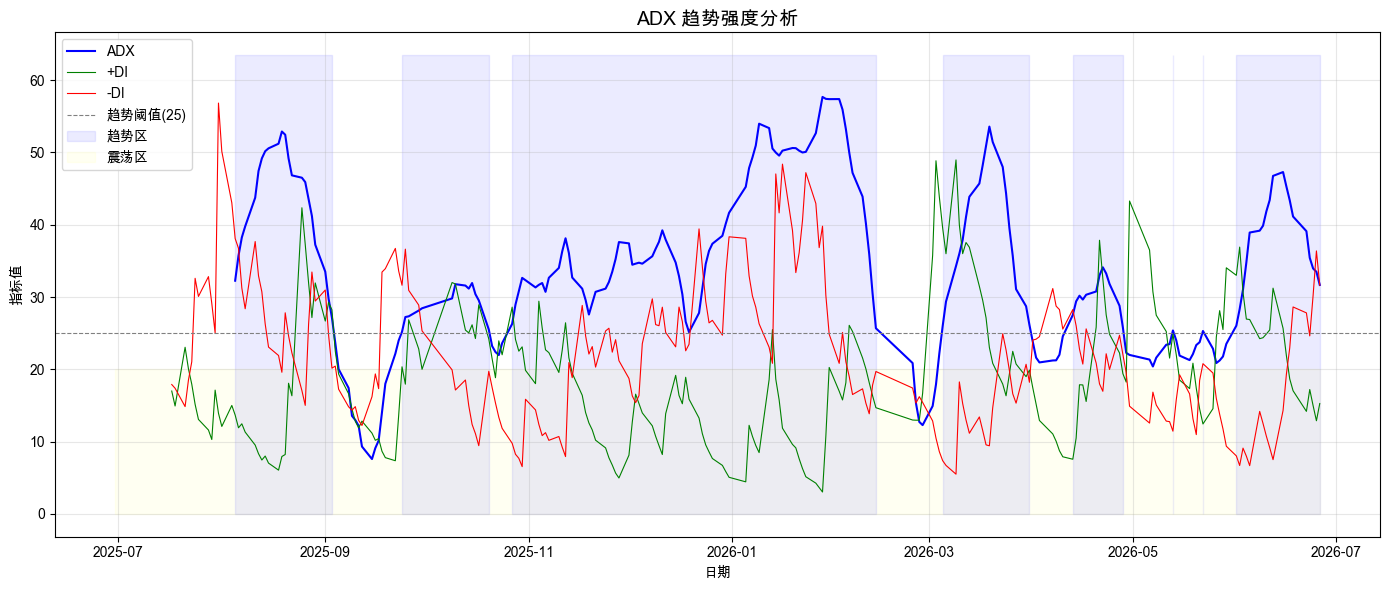

In [9]:
# ADX 计算
high_diff = df['high_qfq'] - df['high_qfq'].shift(1)
low_diff = df['low_qfq'].shift(1) - df['low_qfq']

plus_dm = np.where((high_diff > low_diff) & (high_diff > 0), high_diff, 0.0)
minus_dm = np.where((low_diff > high_diff) & (low_diff > 0), low_diff, 0.0)

plus_dm_series = pd.Series(plus_dm, index=df.index)
minus_dm_series = pd.Series(minus_dm, index=df.index)

df['plus_DI'] = 100 * plus_dm_series.ewm(span=14, adjust=False).mean() / df['ATR14']
df['minus_DI'] = 100 * minus_dm_series.ewm(span=14, adjust=False).mean() / df['ATR14']
df['DX'] = (df['plus_DI'] - df['minus_DI']).abs() / (df['plus_DI'] + df['minus_DI']) * 100
df['ADX'] = df['DX'].rolling(14).mean()

# 信号判断
last = df.iloc[-1]
print('=== ADX 信号判断 ===')
print(f'ADX: {last["ADX"]:.2f}')
print(f'+DI: {last["plus_DI"]:.2f}, -DI: {last["minus_DI"]:.2f}')

if last['ADX'] > 25:
    print('趋势强度：趋势明确')
    if last['plus_DI'] > last['minus_DI']:
        print('方向：上升趋势（+DI > -DI）')
    else:
        print('方向：下降趋势（-DI > +DI）')
elif last['ADX'] < 20:
    print('趋势强度：无趋势（震荡/盘整）')
else:
    print('趋势强度：趋势形成中')

prev_adx = df.iloc[-2]['ADX']
if last['ADX'] > prev_adx:
    print('ADX 方向：趋势增强')
else:
    print('ADX 方向：趋势减弱')

# 绘图
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['trade_date'], df['ADX'], label='ADX', color='blue', linewidth=1.5)
ax.plot(df['trade_date'], df['plus_DI'], label='+DI', color='green', linewidth=0.8)
ax.plot(df['trade_date'], df['minus_DI'], label='-DI', color='red', linewidth=0.8)
ax.axhline(y=25, color='gray', linestyle='--', linewidth=0.8, label='趋势阈值(25)')

# 背景色填充
ax.fill_between(df['trade_date'], 0, df['ADX'].max() * 1.1,
                where=df['ADX'] > 25, alpha=0.08, color='blue', label='趋势区')
ax.fill_between(df['trade_date'], 0, 20, alpha=0.05, color='yellow', label='震荡区')

ax.set_title('ADX 趋势强度分析', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('指标值')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 模块 9：趋势动量综合诊断

In [10]:
last = df.iloc[-1]
prev = df.iloc[-2]

# ===== 9.1 趋势维度 =====
print('=' * 60)
print('趋势动量综合诊断')
print('=' * 60)

# 均线排列
if pd.notna(last['MA20']) and pd.notna(last['MA60']) and pd.notna(last['MA120']):
    if last['close_qfq'] > last['MA20'] > last['MA60'] > last['MA120']:
        ma_align = '多头排列'
        ma_strength = '强'
    elif last['close_qfq'] < last['MA20'] < last['MA60'] < last['MA120']:
        ma_align = '空头排列'
        ma_strength = '强'
    else:
        ma_align = '交叉排列'
        ma_strength = '弱'
else:
    ma_align = '数据不足'
    ma_strength = '-'

# MA5-MA20 交叉
if prev['MA5'] <= prev['MA20'] and last['MA5'] > last['MA20']:
    ma_cross = '金叉'
elif prev['MA5'] >= prev['MA20'] and last['MA5'] < last['MA20']:
    ma_cross = '死叉'
else:
    ma_cross = '无'

# MACD 信号
if prev['DIF'] <= prev['DEA'] and last['DIF'] > last['DEA']:
    macd_cross = '金叉'
elif prev['DIF'] >= prev['DEA'] and last['DIF'] < last['DEA']:
    macd_cross = '死叉'
else:
    macd_cross = '无'
macd_zero = '零轴上' if last['DIF'] > 0 else '零轴下'
macd_signal = f'{macd_zero}+{macd_cross}'
macd_bar_dir = '放大' if abs(last['MACD_bar']) > abs(prev['MACD_bar']) else '缩小'

# 布林带
if last['BB_pctB'] > 0.8:
    bb_pos = '上轨附近'
elif last['BB_pctB'] < 0.2:
    bb_pos = '下轨附近'
else:
    bb_pos = '中轨附近'
bb_bw = '收缩' if last['BB_BW'] < df['BB_BW'].mean() else '扩张'

# ADX
adx_strength = f'{last["ADX"]:.1f}'
adx_trend = '有趋势' if last['ADX'] > 25 else '无趋势'
adx_dir = '+DI > -DI' if last['plus_DI'] > last['minus_DI'] else '-DI > +DI'

trend_data = {
    '类别': ['均线系统', '均线系统', 'MACD', 'MACD', '布林带', '布林带', 'ADX', 'ADX'],
    '指标': ['均线排列', 'MA5-MA20 交叉', 'DIF-DEA 位置', '柱状图方向', '价格位置', '带宽状态', '趋势强度', '方向'],
    '当前信号': [ma_align, ma_cross, macd_signal, macd_bar_dir, bb_pos, bb_bw, adx_trend, adx_dir],
    '信号强度': [ma_strength, '-', '-', '-', '-', '-', adx_strength, '-']
}
trend_df = pd.DataFrame(trend_data)
print('\n【趋势维度】')
print(trend_df.to_string(index=False))

# ===== 9.2 动量维度 =====
# RSI
rsi_val = last['RSI14']
if rsi_val > 70: rsi_sig = '超买'
elif rsi_val < 30: rsi_sig = '超卖'
else: rsi_sig = '中性'

# KDJ
kdj_val = f'K={last["K"]:.1f}/D={last["D"]:.1f}/J={last["J"]:.1f}'
if last['K'] > 80: kdj_sig = '超买'
elif last['K'] < 20: kdj_sig = '超卖'
else: kdj_sig = '中性'

if prev['K'] <= prev['D'] and last['K'] > last['D']:
    kdj_cross = '金叉'
elif prev['K'] >= prev['D'] and last['K'] < last['D']:
    kdj_cross = '死叉'
else:
    kdj_cross = '无'

# 成交量
vol_ratio_val = f'{last["vol_ratio"]:.2f}'
vol_sig = '放量' if last['vol_ratio'] > 1.2 else '缩量' if last['vol_ratio'] < 0.8 else '正常'

price_up = last['close_qfq'] > prev['close_qfq']
vol_up = last['vol'] > prev['vol']
if price_up and vol_up: vp = '量价齐升'
elif price_up and not vol_up: vp = '缩量涨'
elif not price_up and vol_up: vp = '放量跌'
else: vp = '缩量跌'

# ATR
atr_pct_val = f'{last["ATR_pct"]:.2f}%'
if last['ATR14'] > df['ATR14'].mean() * 1.2: atr_sig = '波动偏高'
elif last['ATR14'] < df['ATR14'].mean() * 0.8: atr_sig = '波动偏低'
else: atr_sig = '波动正常'

momentum_data = {
    '类别': ['RSI', 'KDJ', 'KDJ', '成交量', '成交量', 'ATR'],
    '指标': ['RSI(14)', 'K/D/J', '交叉', '量比', '量价关系', 'ATR(14)百分比'],
    '当前值': [f'{rsi_val:.1f}', kdj_val, kdj_cross, vol_ratio_val, vp, atr_pct_val],
    '信号': [rsi_sig, kdj_sig, '-', vol_sig, vp, atr_sig]
}
momentum_df = pd.DataFrame(momentum_data)
print('\n【动量维度】')
print(momentum_df.to_string(index=False))

# ===== 9.3 综合评分 =====
score = 0

# 均线排列（权重 20）
if ma_align == '多头排列': score += 20
elif ma_align == '空头排列': score -= 20

# MACD（权重 20）
if last['DIF'] > 0 and last['DIF'] > last['DEA']: score += 20
elif last['DIF'] < 0 and last['DIF'] < last['DEA']: score -= 20
elif last['DIF'] > last['DEA']: score += 10
elif last['DIF'] < last['DEA']: score -= 10

# RSI（权重 15）
if rsi_val > 70: score -= 10
elif rsi_val < 30: score += 10
elif rsi_val > 50: score += 5
else: score -= 5

# KDJ（权重 15）
if last['K'] > 80: score -= 10
elif last['K'] < 20: score += 10
elif last['K'] > last['D']: score += 5
else: score -= 5

# ADX（权重 15）
if last['ADX'] > 25:
    if last['plus_DI'] > last['minus_DI']: score += 15
    else: score -= 15

# 量价（权重 15）
if vp == '量价齐升': score += 15
elif vp == '放量跌': score -= 15
elif vp == '缩量涨': score += 5
elif vp == '缩量跌': score -= 5

score = max(-100, min(100, score))

if score > 50: verdict = '偏多'
elif score > 20: verdict = '中性偏多'
elif score < -50: verdict = '偏空'
elif score < -20: verdict = '中性偏空'
else: verdict = '中性'

print(f'\n【综合评分】{score} / 100（{verdict}）')
print(f'  +100 = 极度看多, 0 = 中性, -100 = 极度看空')

趋势动量综合诊断

【趋势维度】
  类别          指标      当前信号 信号强度
均线系统        均线排列      交叉排列    弱
均线系统 MA5-MA20 交叉         无    -
MACD  DIF-DEA 位置     零轴下+无    -
MACD       柱状图方向        缩小    -
 布林带        价格位置      下轨附近    -
 布林带        带宽状态        扩张    -
 ADX        趋势强度       有趋势 31.7
 ADX          方向 -DI > +DI    -

【动量维度】
 类别         指标                 当前值   信号
RSI    RSI(14)                42.8   中性
KDJ      K/D/J K=15.2/D=18.4/J=8.7   超卖
KDJ         交叉                   无    -
成交量         量比                1.00   正常
成交量       量价关系                 缩量涨  缩量涨
ATR ATR(14)百分比               1.72% 波动偏高

【综合评分】-25 / 100（中性偏空）
  +100 = 极度看多, 0 = 中性, -100 = 极度看空
